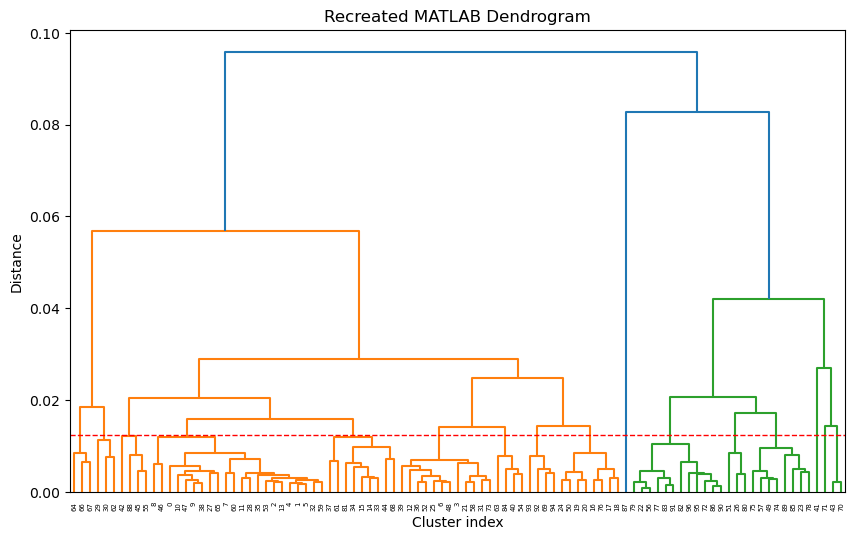

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd


# Load MATLAB linkage matrix
Z = np.loadtxt(r"Z:\Members\Mia-Sanjana-Hadent\Processed Data\042025_2mp\linkage_matlab.csv", delimiter=",")

threshold = Z[0,0]
Z = Z[1:,:]
def add_sample_counts(Z):
    """
    Add the 4th column (cluster sizes) required by SciPy dendrogram.
    Assumes Z is (n-1, 3) with 0-based indices.
    """
    Z = Z.copy()
    n = Z.shape[0] + 1

    counts = np.zeros(Z.shape[0], dtype=int)

    for i in range(Z.shape[0]):
        c1, c2 = int(Z[i, 0]), int(Z[i, 1])

        def cluster_size(c):
            if c < n:
                return 1
            else:
                return counts[c - n]

        counts[i] = cluster_size(c1) + cluster_size(c2)

    return np.column_stack([Z, counts])


# Convert MATLAB (1-based) → Python (0-based)
Z[:, 0:2] -= 1

# Add 4th column
Z = add_sample_counts(Z)


# Plot dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.axhline(y=threshold, color="red", linestyle="--", linewidth=1)
plt.title("Recreated MATLAB Dendrogram")
plt.xlabel("Cluster index")
plt.ylabel("Distance")
plt.show()


In [6]:

Z_levels = Z.copy()
max_distance = np.max(Z[:, 2])
# Example custom thresholds (distance values)
custom_thresholds = [threshold, threshold*2, threshold*4, threshold*8]  # 4 thresholds for 5 levels
custom_thresholds = np.linspace(threshold, max_distance*0.5, 4, endpoint=False)

# Make sure they are sorted ascending
custom_thresholds = np.sort(custom_thresholds)
# Assign each merge to a level 1–5 based on custom thresholds
for i in range(Z_levels.shape[0]):
    dist = Z_levels[i, 2]
    level = np.sum(dist > custom_thresholds) + 1  # level from 1 to 5
    Z_levels[i, 2] = level


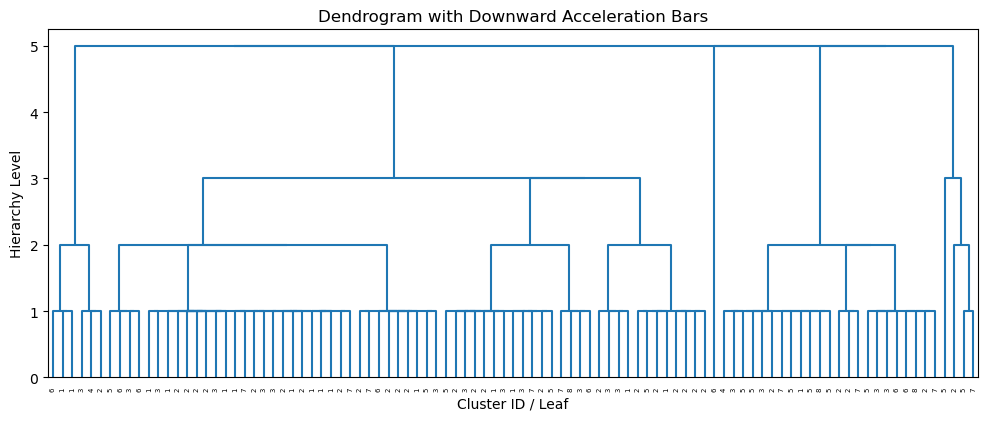

In [21]:

df = pd.read_csv(r"C:\Users\gangliagurdian\Desktop\Hadents Folder\Visualization_2mp\data\combined_results_2mp_with_accel.csv")

import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Compute average acceleration per cluster
cluster_acc = df.groupby('Cluster')['TotAccelBA'].mean()

# 2️⃣ Compute dendrogram without plotting to get leaf positions
ddata = dendrogram(Z_levels, no_plot=True)
leaf_order = ddata['leaves']  # original observation indices
leaf_clusters = df['Cluster'].iloc[leaf_order].values

# 3️⃣ Get average acceleration for each leaf
ordered_acceleration = [cluster_acc.get(cl, 0) for cl in leaf_clusters]

# 4️⃣ Plot dendrogram
plt.figure(figsize=(12, 6))
ddata_plot = dendrogram(Z_levels, color_threshold=0)
ax = plt.gca()

# 5️⃣ Get leaf x-coordinates from dendrogram
# dendrogram['ivl'] gives leaf labels as strings, 'leaves' gives leaf order
# 'dcoord' and 'icoord' store the vertical and horizontal line segments
# For bars, we can get the center of each leaf from dendrogram's plotting
icoord = np.array(ddata_plot['icoord'])  # shape: (n_links, 4)
dcoord = np.array(ddata_plot['dcoord'])
# The leaf x-positions are at the middle of the bottom of each 'U' (i.e., first & last of each icoord)
# But easier: dendrogram plots leaves in order, so x positions are just 5, 15, 25,... for default
leaf_x = np.arange(5, 5 + 10*len(leaf_order), 10)  # default dendrogram spacing

# 6️⃣ Plot downward bars aligned with leaf x-coordinates
for x, acc in zip(leaf_x, ordered_acceleration):
    ax.vlines(x=x, ymin=0, ymax=-acc, color='skyblue', linewidth=2)

# 7️⃣ Set x-ticks to match leaves
ax.set_xticks(leaf_x)
ax.set_xticklabels([str(cl) for cl in leaf_clusters], rotation=90)

# 8️⃣ Labels and title
ax.set_ylabel("Hierarchy Level")
ax.set_xlabel("Cluster ID / Leaf")
plt.title("Dendrogram with Downward Acceleration Bars")

# 9️⃣ Make room for downward bars
plt.subplots_adjust(bottom=0.3)
plt.show()




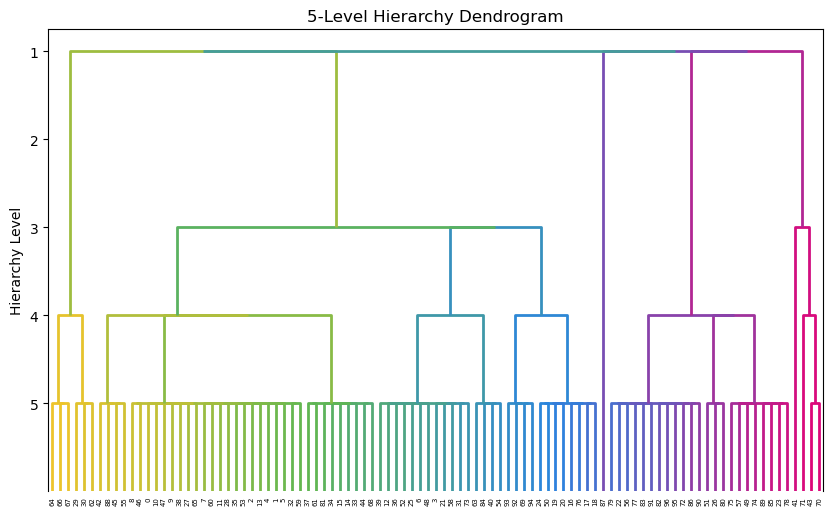

In [3]:
plt.figure(figsize=(10, 6))
ddata = dendrogram(Z_levels)

ax = plt.gca()


# Get ALL dendrogram line collections
line_collections = [c for c in ax.collections if isinstance(c, LineCollection)]

# Gather all segments from all collections
all_segments = []
segment_map = []  # Track which collection each segment belongs to

for lc in line_collections:
    segments = lc.get_segments()
    for seg in segments:
        all_segments.append(seg)
        segment_map.append(lc)

# Compute average x-position of each segment
x_means = [np.mean(seg[:, 0]) for seg in all_segments]

# Sort segments left → right
sorted_indices = np.argsort(x_means)

# Custom gradient
cmap = LinearSegmentedColormap.from_list(
    "custom_gradient",
    ["#eec42b", "#61b751", "#2a84df", "#dd077a"]
)

n = len(all_segments)
gradient_positions = np.linspace(0, 1, n)
smooth_colors = [cmap(p) for p in gradient_positions]

# Reorder colors to original segment order
final_colors = [None] * n
for sorted_pos, original_idx in enumerate(sorted_indices):
    final_colors[original_idx] = smooth_colors[sorted_pos]

# Apply colors back to their respective collections
start = 0
for lc in line_collections:
    lc.set_linewidth(2)
    seg_count = len(lc.get_segments())
    lc.set_color(final_colors[start:start + seg_count])
    start += seg_count
ax = plt.gca()

# Hide the bottom axis line (spine)
ax.spines['bottom'].set_visible(False)


plt.ylabel("Hierarchy Level")

# Keep tick positions the same
plt.yticks(range(1, 5 + 1),
           labels=list(range(5, 0, -1)))

plt.title("5-Level Hierarchy Dendrogram")

# Keep the tick labels
ax.tick_params(axis='x', length=0)  # optional: removes tick marks but keeps labels
plt.show()
